In [1]:
from pathlib import Path
import sys
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, MinMaxScaler

project_root = None
for base in [Path.cwd(), *Path.cwd().parents]:
    src_candidate = base / "src" / "trajectoryclusteringanalysis"
    if src_candidate.exists():
        project_root = base
        break

if project_root is None:
    raise FileNotFoundError(
        f"Could not find project root containing src/trajectoryclusteringanalysis from {Path.cwd()}"
    )

src_path = project_root / "src"
if str(src_path) not in sys.path:
    sys.path.insert(0, str(src_path))

from trajectoryclusteringanalysis import TCA
from trajectoryclusteringanalysis.plotting import *

print(f"Using local package from: {src_path}")

from trajectoryclusteringanalysis.tca import TCA

Using local package from: c:\Users\imen.miloudi\OneDrive - Aix-Marseille Université\Documents\stage\TrajectoryClusteringAnalysis\src


In [2]:
df_synthea = pd.read_csv(project_root / "data" / "multidimensional_synthea_10k.csv")

# Dictionnaire pour simplifier les noms des médicaments
medication_mapping = {
    'NDA020503 200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler': 'Albuterol Inhaler',
    '120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler': 'Fluticasone Inhaler',
    'insulin human  isophane 70 UNT/ML / Regular Insulin  Human 30 UNT/ML Injectable Suspension [Humulin]': 'Insulin',
    '24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet': 'Metformin',
    'Hydrochlorothiazide 25 MG Oral Tablet': 'HCTZ 25mg',
    'amLODIPine 5 MG / Hydrochlorothiazide 12.5 MG / Olmesartan medoxomil 20 MG Oral Tablet': 'Amlodipine Combo',
    'Atenolol 50 MG / Chlorthalidone 25 MG Oral Tablet': 'Atenolol Combo',
    'Hydrochlorothiazide 12.5 MG': 'HCTZ 12.5mg',
    'Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray': 'Nitroglycerin Spray',
    'Simvastatin 10 MG Oral Tablet': 'Simvastatin 10mg'
}

df_synthea['medication_events'] = df_synthea['medication_events'].map(medication_mapping)

print(f"Nombre de patients : {df_synthea['patient_id'].nunique()}")
print(f"Temps de suivi max (jours) : {df_synthea['time'].max()}")
df_synthea.head()

Nombre de patients : 901
Temps de suivi max (jours) : 179


,patient_id,time,medication_events
0,1,11,Fluticasone Inhaler
1,1,11,Albuterol Inhaler
2,1,22,Fluticasone Inhaler
3,1,22,Albuterol Inhaler
4,1,35,Fluticasone Inhaler


In [3]:
label_encoder = LabelEncoder()
timed_event_structure = df_synthea.copy()

timed_event_structure['Event'] = label_encoder.fit_transform(timed_event_structure['medication_events'])
timed_event_structure.drop(columns=['medication_events'], inplace=True)

timed_event_structure.columns = ['ID_PATIENT', 'Time', 'Event']
noms_events = label_encoder.classes_

tca = TCA(data=timed_event_structure,
          index_col='ID_PATIENT',
          time_col='Time', 
          event_col='Event',
          mode='multidimensional'
         )

tca.analyzer.transform_time_event_structure_to_tensor()
print("Tensor shape:", tca.analyzer.get_tensor_shape())
tensor = tca.analyzer.get_tensor()

INFO:root:TCA object initialized successfully


INFO:root:The multidimensional analysis mode is set. TCA object will analyze the data accordingly.


Dataset :
data shape:  (30753, 3)
state coding:
    label  label encoded
0      0              0
1      1              1
2      2              2
3      3              3
4      4              4
5      5              5
6      6              6
7      7              7
8      8              8
9      9              9
Tensor shape: torch.Size([901, 10, 180])


Patient utilisé pour la visualisation: 21


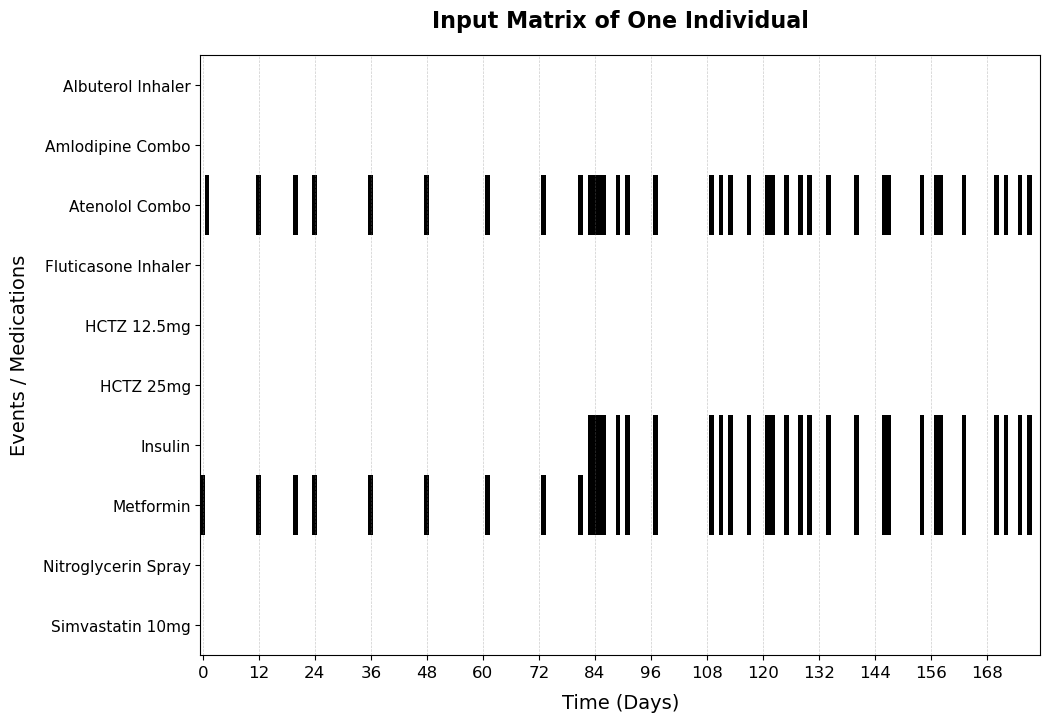

In [4]:
# Hyperparamètres
rank = 3
reg_term_ns = 0.05
reg_term_s = 0.05
metric = 'Bernoulli'
learning_rate = 1e-3
n_epochs = 150 

# Tailles 1 semaine, 2 semaines, 3 semaines, 1 mois
tailles_fenetres = [7, 14, 21, 30] 

# Un patient avec au moins 3/4 traitements diff.
patients_complexes = timed_event_structure.groupby('ID_PATIENT').filter(
    lambda group: len(set(group['Event'])) >= 3
)['ID_PATIENT'].unique()

patient_index = int(patients_complexes[0])
print(f"Patient utilisé pour la visualisation: {patient_index}")

plot_input_matrix(tensor, id=patient_index, labels=noms_events, time_unit="Days")

In [5]:
# Hyperparametres de la demo
rank = 3
reg_term_ns = 0.5
reg_term_s = 0.5
metric = 'Bernoulli'
learning_rate = 1e-3
n_epochs = 5  # 30 pour demo rapide, 100+ pour entrainement plus stable

GPU available: False, used: False
TPU available: False, using: 0 TPU cores
c:\Users\imen.miloudi\AppData\Local\anaconda3\envs\stage\lib\site-packages\lightning\pytorch\trainer\connectors\logger_connector\logger_connector.py:76: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
💡 Tip: For seamless cloud uploads and versioning, try installing [litmodels](https://pypi.org/project/litmodels/) to enable LitModelChec

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=5` reached.


Decomposed into 901 pathways with rank 3 and time window length 3
FIT metric for the entire dataset: -7.3354
success_rate :-7.6897545913592165


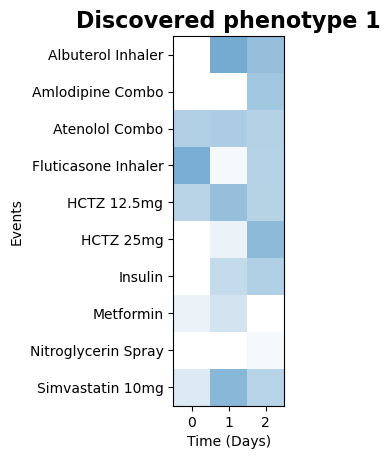

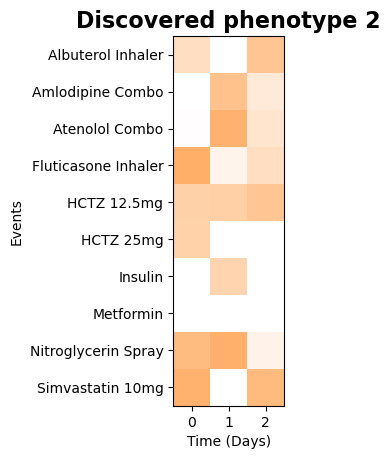

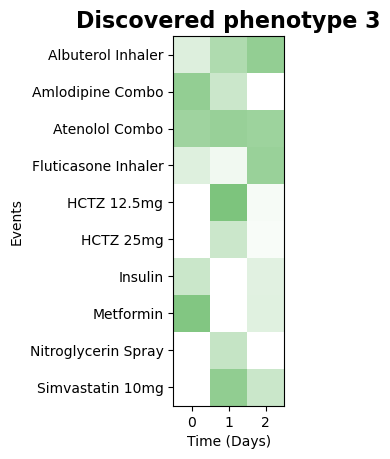

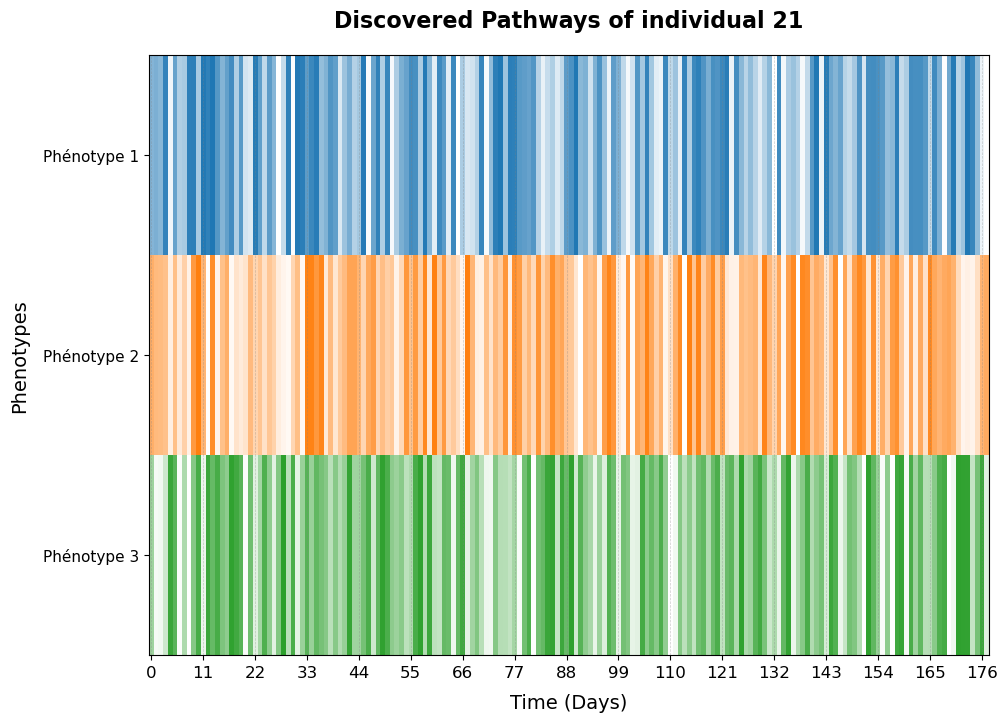

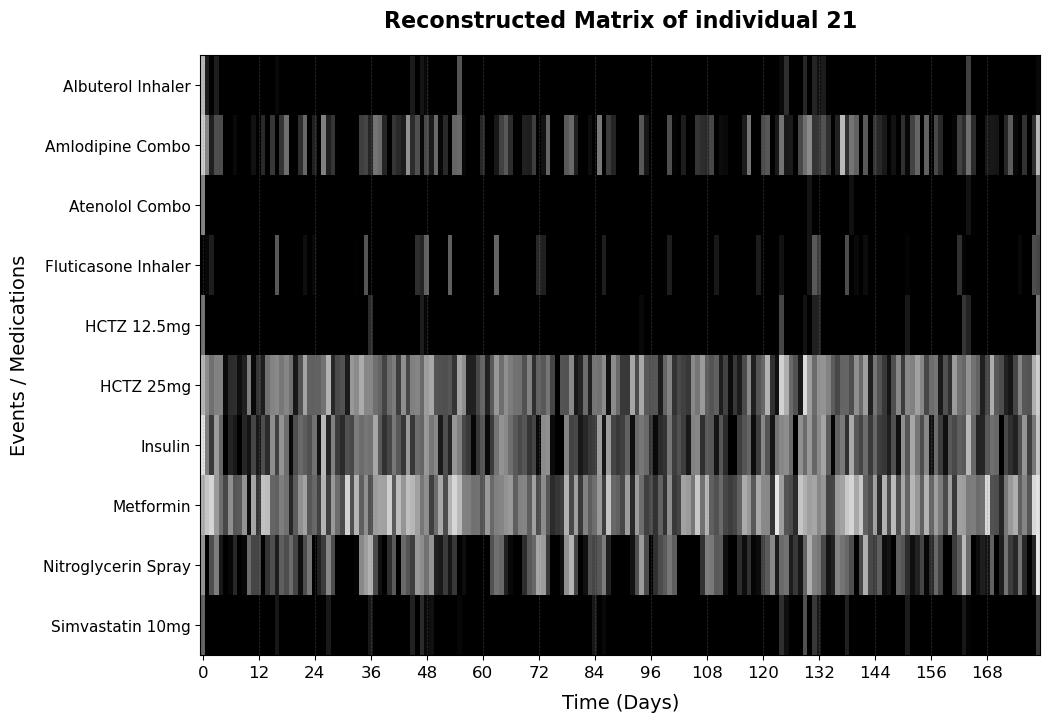

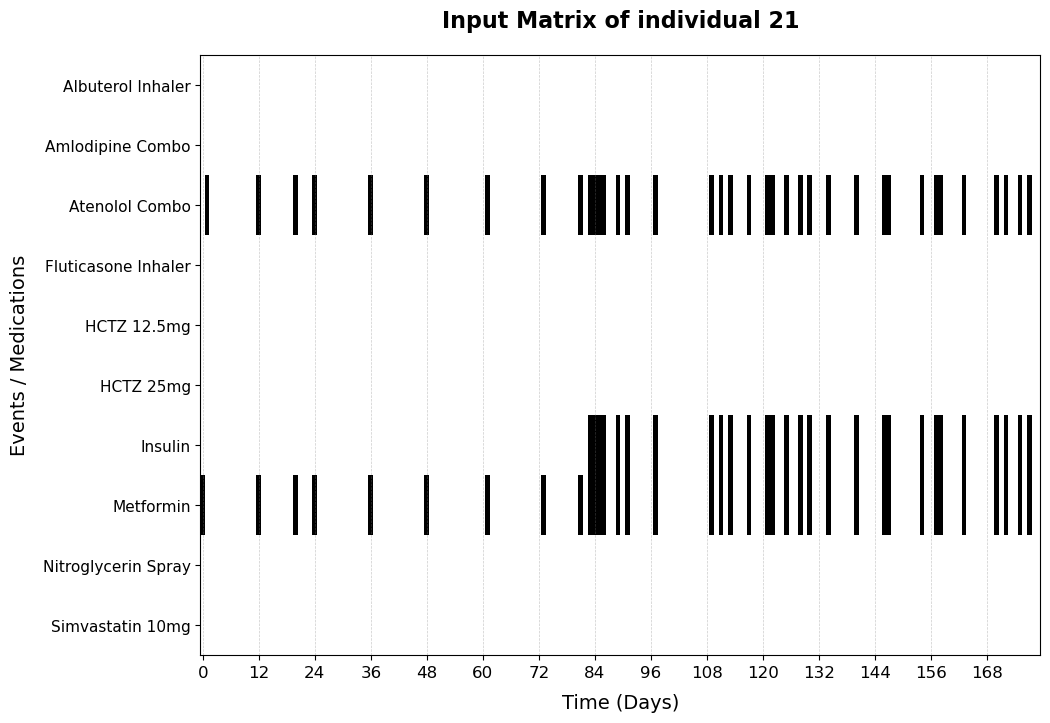

In [6]:
tca.analyzer.fit_swotted_decomposition(
        tensor=tensor,
        rank=rank,
        time_window_length=3,
        reg_term_ns=reg_term_ns,
        reg_term_s=reg_term_s,
        metric=metric,
        learning_rate=learning_rate,
        n_epochs=n_epochs
    )

tca.analyzer.get_decomposition_results(labels=noms_events, id=patient_index, time_unit="Days")